In [1]:

# basic stuff
import torch
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import OrderedDict

# tsl
from tsl.data import SpatioTemporalDataset
from tsl.data.datamodule import (SpatioTemporalDataModule,
                                 TemporalSplitter)
from tsl.data.preprocessing import StandardScaler
from tsl.metrics.torch import MaskedMAE, MaskedMAPE
from tsl.engines import Predictor

# pytorch lightning
from pytorch_lightning.loggers import TensorBoardLogger
import pytorch_lightning as ptl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

# optuna
import optuna
# from optuna.integration import PyTorchLightningPruningCallback

# architecture from paper
from lib.nn.encoders.corel_encoder import CoRelEncoder
from lib.nn.decoder.base_decoder import BaseDecoder
from lib.nn.encoder_decoder_model import EncoderDecoderModel

# reproducibility
ptl.seed_everything(42)


c:\Users\matya\OneDrive\Bureau\Semester_project\SemesterProject\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


42

In [2]:
df = pd.read_csv('../data/EWZ_cleaned.csv', index_col=0)

df.head()

,Wärmezähler UST 10 Spitalstrasse 6 Regionalspital Surselva WZ11,Wärmezähler Fernleitung WZ6,Wärmezähler Rückkühler WT04 WZ4,Wärmezähler UST 01 Bahnhofstrasse 14,Wärmezähler UST 11 Via Schlifras 46,Wärmezähler UST 12 Via Schlifras 48,Wärmezähler UST 13 Via Schlifras 50,Wärmezähler UST 14 Via Schlifras 54,Wärmezähler UST 15 Solaranlage BWW,Wärmezähler UST 16 Via Schlifras 66/68/70,...,Wärmezähler UST 80 Via Santeri 6,Wärmezähler UST 81 Via Santeri 4,"Wärmezähler UST 82 Via S. Clau Sut 2,4",Wärmezähler UST 83 Glennerstrasse 18,Wärmezähler Spitalstrasse 7 UST 84,Wärmezähler Spitalstrasse 8 UST 85,Wärmezähler UST 86 Valserstrasse 7,Wärmezähler UST 87 Via Hans Erni 6,Wärmezähler UST 88 Glennerstrasse 10,Wärmezähler Via Schlifras 62/64 UST 89
Time,,,,,,,,,,,,,,,,,,,,,
2021-11-01 00:00:00,0.0229,0.2578,0.0,0.0233,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000,0.000,0.000,0.0109,0.0004,0.005,0.0000,0.0096,0.0066
2021-11-01 00:15:00,0.0176,0.3047,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.002,0.007,0.001,0.0109,0.0004,0.000,0.0000,0.0096,0.0066
2021-11-01 00:30:00,0.0161,0.2188,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000,0.000,0.000,0.0109,0.0004,0.004,0.0000,0.0096,0.0066
2021-11-01 00:45:00,0.0166,0.2734,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.001,0.000,0.002,0.0109,0.0004,0.000,0.0010,0.0096,0.0066
2021-11-01 01:00:00,0.0186,0.2891,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.001,0.000,0.000,0.0109,0.0004,0.005,0.0008,0.0096,0.0066


In [3]:


torch_dataset_hour_forecast = SpatioTemporalDataset(target=df,
                                      horizon=4,
                                      window=4 * 24,
                                      stride=1)


# Use later on

# torch_dataset_day_forecast = SpatioTemporalDataset(target=df,
#                                       horizon=4 * 24,
#                                       window=4 * 24 * 7,
#                                       stride=1)

In [4]:


# Normalize data using mean and std computed over time and node dimensions
scalers = {'target': StandardScaler(axis=(0, 1))}

# Split data sequentially:
splitter = TemporalSplitter(val_len=0.1, test_len=0.25)

dm = SpatioTemporalDataModule(
    dataset=torch_dataset_hour_forecast,
    scalers=scalers,
    splitter=splitter,
    batch_size=64,
)

input_size = torch_dataset_hour_forecast.n_channels  
n_nodes = torch_dataset_hour_forecast.n_nodes        
horizon = torch_dataset_hour_forecast.horizon         

### Load trained model

In [6]:



model = EncoderDecoderModel(
    input_size=input_size,
    output_size=input_size,
    horizon=horizon,
    encoder_class=CoRelEncoder,
    encoder_kwargs={'gnn_layers': spatial_layers, 'temporal_layers': temporal_layers,
                    'hidden_size': hidden_size, 'n_instances': n_nodes, 'emb_size': hidden_size,
                    'n_neighbors': k, 'conv_type': conv_type,},
    decoder_class=BaseDecoder,
    decoder_kwargs={},
    exog_size= 0,
)

checkpoint = torch.load("./logs/epoch=19-step=200.ckpt", weights_only=False)
state_dict = checkpoint["state_dict"]

# fix error with 'model.' prefix
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_key = k.replace("model.", "") 
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict, strict=True)
model.eval()



EncoderDecoderModel(
  (encoder): CoRelEncoder(
    (emb): NodeEmbedding(n_nodes=83, embedding_size=32)
    (input_encoder): Linear(in_features=33, out_features=32, bias=True)
    (temporal_encoder): RNN(
      (rnn): GRU(32, 32)
    )
    (gnn_layers): ModuleList(
      (0): DiffConv(32, 32)
    )
    (graph_learning_module): DifferentiableKnnGraphLayer(
      (sampler): StraightThroughSubsetSampler()
      (logits): AdjEmb()
    )
  )
  (decoder): BaseDecoder(
    (decoder): Linear(in_features=96, out_features=4, bias=True)
    (rearrange): Rearrange('b n (t f) -> b t n f', t=4)
  )
)

### Plot prediction on test set

In [7]:
df_test = pd.read_csv('../data/EWZ_test.csv', index_col=0)


torch_dataset_test = SpatioTemporalDataset(target=df_test,
                                      horizon=4,
                                      window=4 * 24,
                                      stride=1)



c:\Users\matya\OneDrive\Bureau\Semester_project\SemesterProject\src\lib\nn\utils.py:12: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:322.)
  emb = emb[[None] * (x.ndim - emb.ndim)]


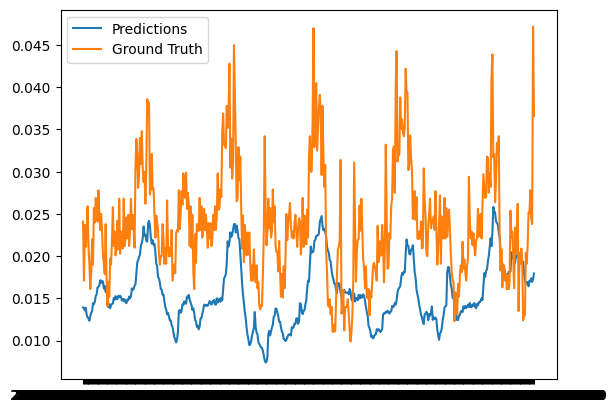

In [ ]:


cols = df_test.columns
col_idx = 0

n_pred = 500

preds = np.zeros(n_pred)

for i in range(n_pred):
    preds[i] = model(torch_dataset_test[i].input.x.unsqueeze(0))[0,0,col_idx, 0]
    torch.cuda.empty_cache()


truth = [torch_dataset_test[i].input.x.unsqueeze(0)[0,0,col_idx, 0] for i in range(n_pred)]


plt.plot(df_test.index[:n_pred], preds, label='Predictions')
plt.plot(df_test.index[:n_pred], truth, label='Ground Truth')
plt.legend()
plt.show()


### Hyperparameter selection with optuna

[Source](https://machinelearningmastery.com/pytorch-lightning-hyperparameter-optimization-with-optuna/)

In [5]:
def objective(trial):

    conv_type = trial.suggest_categorical('conv_type', ['diffconv', 'graphconv'])   
    temporal_type = trial.suggest_categorical('temporal_type', ["gru", "lstm"])
    hidden_size = trial.suggest_categorical('hidden_dim', [16, 32, 64, 128])
    k = trial.suggest_int('k', 1, 5)
    spatial_layers = trial.suggest_int('spatial_layers', 1, 2)
    temporal_layers = trial.suggest_int('temporal_layers', 1, 5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)


    stgnn = EncoderDecoderModel(
    input_size=input_size,
    output_size=input_size,
    horizon=horizon,
    encoder_class=CoRelEncoder,
    encoder_kwargs={'gnn_layers': spatial_layers, 'temporal_layers': temporal_layers,
                    'hidden_size': hidden_size, 'n_instances': n_nodes, 'emb_size': hidden_size,
                    'n_neighbors': k, 'conv_type': conv_type, "temporal_type": temporal_type},
    decoder_class=BaseDecoder,
    decoder_kwargs={},
    exog_size= 0,
    )


    

    logger = TensorBoardLogger(save_dir="logs", name=f"optuna_logs/trial_{trial.number}")

    loss_fn = MaskedMAE()

    metrics = {'mae': MaskedMAE(),}

    # setup predictor
    predictor = Predictor(
        model=stgnn,                  
        optim_class=torch.optim.Adam,  
        optim_kwargs={'lr': learning_rate},    
        loss_fn=loss_fn,               
        metrics=metrics               
    )



    early_stop_callback = EarlyStopping(
        monitor='val_loss',
        patience=5,
        verbose=False,
        mode='min'
    )

    # Cant find work around to use it : https://github.com/Lightning-AI/pytorch-lightning/issues/17485
    # pruning_callback = PyTorchLightningPruningCallback(trial, monitor='val_loss')


    trainer = ptl.Trainer(max_epochs=10,
                        logger=logger,
                        limit_train_batches=25,
                        callbacks=[early_stop_callback]) #, pruning_callback])
    

    trainer.fit(predictor, datamodule=dm)

    return trainer.callback_metrics['val_loss'].item()


In [12]:
def run_optimization(n_trials=20):
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10) # should I keep this ?
    study = optuna.create_study(direction='minimize', pruner=pruner)
    study.optimize(objective, n_trials=n_trials)
    
    print("Best trial:")
    trial = study.best_trial
    print(f"  Value: {trial.value}")
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
        
    return study

study = run_optimization()
best_params = study.best_trial.params


[I 2025-09-27 13:47:36,613] A new study created in memory with name: no-name-9f6a765f-b480-4c9b-9847-12560a26102d
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss_fn       | MaskedMAE           | 0      | train
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | EncoderDecoderModel | 162 K  | train
--------------------------------------------------------------
162 K     Trainable params
0         Non-trainable params
162 K     Total params
0.651     Total esti

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\matya\OneDrive\Bureau\Semester_project\SemesterProject\venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\matya\OneDrive\Bureau\Semester_project\SemesterProject\src\lib\nn\utils.py:12: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:322.)
  emb = emb[[None] * (x.ndim - emb.ndim)]

Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

c:\Users\matya\OneDrive\Bureau\Semester_project\SemesterProject\venv\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
with open("./best_hyperparams_hour_forecast.json", "w") as f:
            json.dump(best_params, f)